# CIHA: atendimentos além do SUS

**Pergunta que este notebook responde:** o que a Comunicação de Internação
Hospitalar e Ambulatorial registra, e como ela complementa o SIH?

**Fonte:** CIHA — registra atendimentos realizados por estabelecimentos que
atendem **também fora do SUS** (convênios e particulares), permitindo enxergar
parte da assistência que não aparece no SIH.
**Tempo estimado:** 3 a 5 minutos.

> ⚠️ **Armadilha desta base:** a função `ciha()` tem `group="CIHA"` como valor
> padrão, e esse valor **faz a consulta devolver zero linhas**. É preciso passar
> `group=None` explicitamente.

## Preparação

In [2]:
%pip install pysus==2.10.6 nest_asyncio -q
import nest_asyncio
nest_asyncio.apply()
print("Ambiente pronto.")

Note: you may need to restart the kernel to use updated packages.
Ambiente pronto.


## Parâmetros

In [3]:
UF = "PR"
ANO = 2023
MES = 1

## Passo 1 — Conferir o catálogo

In [4]:
from pysus import list_files

catalogo = list_files(dataset="ciha", state=UF, year=ANO)
arquivos = sorted(nome.split("\\")[-1] for nome in catalogo["name"])

print(f"Arquivos em {UF}/{ANO}: {len(arquivos)}")
print("Exemplos:", arquivos[:4])

Arquivos em PR/2023: 12
Exemplos: ['CIHAPR2301.parquet', 'CIHAPR2302.parquet', 'CIHAPR2303.parquet', 'CIHAPR2304.parquet']


## Passo 2 — Baixar (com `group=None`)

In [5]:
from pysus import ciha

atendimentos = ciha(state=UF, year=ANO, month=MES, group=None, as_dataframe=True)

print(f"{len(atendimentos):,} atendimentos em {UF}, {MES:02d}/{ANO}")
print(f"{len(atendimentos.columns)} colunas")
print()
print("Se o resultado acima for 0, confira se você passou group=None.")

137,746 atendimentos em PR, 01/2023
30 colunas
Se o resultado acima for 0, confira se você passou group=None.


In [6]:
list(atendimentos.columns)

['ANO_CMPT',
 'MES_CMPT',
 'ESPEC',
 'CGC_HOSP',
 'MUNIC_RES',
 'NASC',
 'SEXO',
 'UTI_MES_TO',
 'UTI_INT_TO',
 'PROC_REA',
 'QT_PROC',
 'DT_ATEND',
 'DT_SAIDA',
 'DIAG_PRINC',
 'DIAG_SECUN',
 'COBRANCA',
 'NATUREZA',
 'GESTAO',
 'MUNIC_MOV',
 'COD_IDADE',
 'IDADE',
 'DIAS_PERM',
 'MORTE',
 'NACIONAL',
 'CAR_INT',
 'HOMONIMO',
 'CNES',
 'FONTE',
 'CGC_CONSOR',
 'MODALIDADE']

## Passo 3 — Principais diagnósticos

In [7]:
import pandas as pd

top = (
    atendimentos["DIAG_PRINC"]
    .value_counts()
    .head(12)
    .rename_axis("CID-10")
    .reset_index(name="Atendimentos")
)
top["%"] = (top["Atendimentos"] / len(atendimentos) * 100).round(2)
top

,CID-10,Atendimentos,%
0,,70457,51.15
1,Z000,10998,7.98
2,A000,5540,4.02
3,Z049,3358,2.44
4,Z010,1322,0.96
5,R103,1227,0.89
6,A09,924,0.67
7,R104,842,0.61
8,Z008,833,0.60
9,M125,829,0.60


## Passo 4 — Perfil por sexo e idade

In [8]:
SEXOS = {"1": "Masculino", "3": "Feminino", "2": "Feminino", "0": "Ignorado", "9": "Ignorado"}

perfil = (
    atendimentos["SEXO"].astype(str).map(SEXOS).fillna("Ignorado")
    .value_counts()
    .rename_axis("Sexo")
    .reset_index(name="Atendimentos")
)
perfil["%"] = (perfil["Atendimentos"] / len(atendimentos) * 100).round(1)
perfil

,Sexo,Atendimentos,%
0,Feminino,78234,56.8
1,Masculino,47765,34.7
2,Ignorado,11747,8.5


## Passo 5 — Procedimentos e permanência

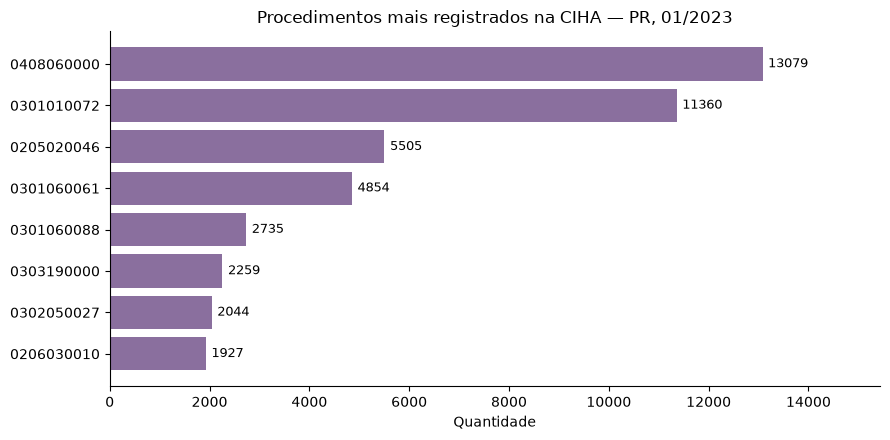

In [9]:
import matplotlib.pyplot as plt

proc = (
    atendimentos["PROC_REA"]
    .value_counts()
    .head(8)
    .rename_axis("Procedimento")
    .reset_index(name="Quantidade")
    .sort_values("Quantidade")
)

fig, ax = plt.subplots(figsize=(9, 4.5))
barras = ax.barh(proc["Procedimento"].astype(str), proc["Quantidade"], color="#8a6f9e")
ax.bar_label(barras, padding=4, fontsize=9)
ax.set_title(f"Procedimentos mais registrados na CIHA — {UF}, {MES:02d}/{ANO}", fontsize=12)
ax.set_xlabel("Quantidade")
ax.set_xlim(0, proc["Quantidade"].max() * 1.18)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

## Como interpretar

A CIHA **não substitui o SIH**: ela cobre estabelecimentos que atendem fora do
SUS e cuja notificação é obrigatória, mas a cobertura varia muito entre estados
e períodos. Use-a como complemento, não como fonte única.

## Como adaptar

- **Outro estado, ano ou mês:** mude os parâmetros — lembrando sempre de
  `group=None`.
- **Um diagnóstico específico:** filtre `DIAG_PRINC`.
- **Por município:** agrupe por `MUNIC_RES`.

## Verificação de sanidade

Toda análise deste repositório termina conferindo o próprio resultado. Não é
formalidade: uma mudança no catálogo do DATASUS já fez notebooks devolverem o
Brasil inteiro rotulado como um estado, **sem erro nenhum**. Falhar alto é
incômodo; acertar o formato e errar o número vira decisão errada.

In [10]:
print("Verificações\n")
falhas = []


def conferir(numero, descricao, condicao, detalhe=""):
    marca = "confere" if condicao else "ATENÇÃO"
    print(f"{numero}. {descricao}{(' — ' + detalhe) if detalhe else ''}: {marca}")
    if not condicao:
        falhas.append(descricao)

def soma(x):
    """Soma numérica de escalar, Series ou DataFrame. Sempre devolve número."""
    import numpy as np
    if isinstance(x, (int, float, np.integer, np.floating)):
        return float(x)
    if isinstance(x, pd.DataFrame):
        return float(x.select_dtypes("number").to_numpy().sum())
    return float(pd.to_numeric(pd.Series(x), errors="coerce").sum())


def quantos(x):
    """Quantidade de itens, aceitando também um número já contado."""
    import numpy as np
    if isinstance(x, (int, float, np.integer, np.floating)):
        return int(x)
    return len(x)


conferir(1, "Vieram atendimentos", len(atendimentos) > 0,
         f"{len(atendimentos):,} registros")
_uf = [c for c in ("UFMUN", "MUNIC_MOV", "UF_ZI") if c in atendimentos.columns]
if _uf:
    prefixos = set(atendimentos[_uf[0]].astype(str).str[:2].unique())
    conferir(2, f"Todos os registros são de um estado só ({_uf[0]})",
             len(prefixos) == 1, f"prefixos: {sorted(prefixos)[:4]}")
conferir(3, "Os procedimentos mais frequentes não somam mais que o total",
         soma(proc) <= len(atendimentos),
         f"{soma(proc):,.0f} de {len(atendimentos):,}")
# soma() percorre TODAS as colunas numericas, e 'perfil' traz uma de
# percentual junto da contagem — somar as duas dava 100 a mais que o total.
_conta = [c for c in perfil.columns if "%" not in str(c)] \
    if hasattr(perfil, "columns") else None
conferir(4, "O perfil por sexo cobre os registros",
         soma(perfil[_conta] if _conta else perfil) <= len(atendimentos),
         f"{soma(perfil[_conta] if _conta else perfil):,.0f} de {len(atendimentos):,}")

print()
if falhas:
    print("ATENÇÃO: revise antes de usar estes números —", falhas)
else:
    print("Tudo confere.")

Verificações
1. Vieram atendimentos — 137,746 registros: confere
2. Todos os registros são de um estado só (MUNIC_MOV) — prefixos: ['41']: confere
3. Os procedimentos mais frequentes não somam mais que o total — 43,763 de 137,746: confere
4. O perfil por sexo cobre os registros — 137,746 de 137,746: confere
Tudo confere.


---
*Notebook do projeto [PySusNoCode](https://github.com/cartaproale/PySusNoCode) —
um produto [Kraemer Academy](https://kraemeracademy.net).
Validado com dados reais do DATASUS.*